In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap, Normalize

sns.set(context='talk')

### single-unit

In [2]:
pca_df      = pd.read_csv('../../results/pca_df.csv')
beh_df      = pd.read_csv('../../results/beh_df.csv')
hidden_stack = np.load('../../results/hidden_stack.npy')  # (n_nets, 60, 10)

boundaries = tuple(sorted(pca_df['boundary'].unique()))  # (0.25, 0.5, 0.75)

In [3]:
pca_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,PC1,PC2,PC3
0,0.25,b=0.25,0.041667,0,0,0.0,-0.287636,0.002265,0.019172
1,0.25,b=0.25,0.041667,1,0,0.0,-0.287636,0.002265,0.019172
2,0.25,b=0.25,0.083333,2,1,0.0,-0.282703,-0.001868,0.011235
3,0.25,b=0.25,0.083333,3,1,0.0,-0.282703,-0.001868,0.011235
4,0.25,b=0.25,0.125000,4,2,0.0,-0.274456,-0.005063,0.004965


In [4]:
beh_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,resp,class_pred,net_idx,stim_aligned,resp_aligned,stim_rank,resp_rank
0,0.25,b=0.25,0.041667,0,0,0.0,0.212022,0.0,0,-0.208333,-0.037978,1.5,1.5
1,0.25,b=0.25,0.041667,1,0,0.0,0.212022,0.0,0,-0.208333,-0.037978,1.5,1.5
2,0.25,b=0.25,0.083333,2,1,0.0,0.212605,0.0,0,-0.166667,-0.037395,3.5,3.5
3,0.25,b=0.25,0.083333,3,1,0.0,0.212605,0.0,0,-0.166667,-0.037395,3.5,3.5
4,0.25,b=0.25,0.125000,4,2,0.0,0.213189,0.0,0,-0.125000,-0.036811,5.5,5.5


In [5]:
hidden_stack.shape

(30, 60, 10)

### PCA

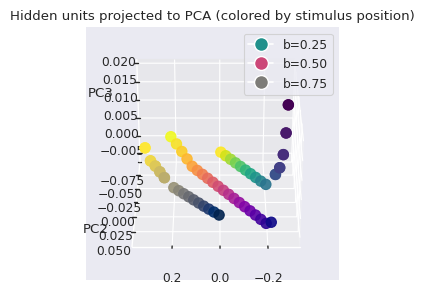

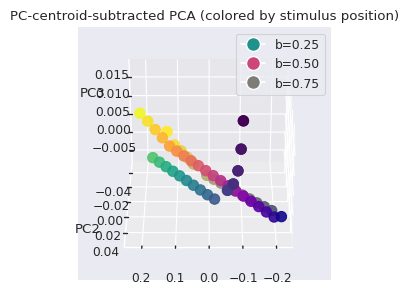

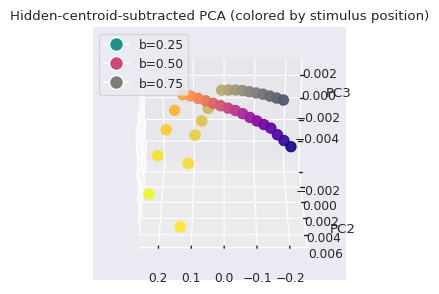

In [6]:
# %matplotlib widget
sns.set(context='paper')
from matplotlib.lines import Line2D

# average hidden activations across networks for each of the 60 trials
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]

# project to 3 PCs (plot 1)
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)

pca_df = pca_df.copy()
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]

# three green->yellow spectra (one per boundary)
cond_cmaps = { 0.25: plt.cm.viridis, 0.50: plt.cm.plasma, 0.75: plt.cm.cividis}

# legend handles using midpoint (0.5) color of each colormap
legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cond_cmaps[bound](0.5), markersize=10,
           label=f'b={bound:.2f}')
    for bound in boundaries
]

# ── View angle (tweak these) ──────────────────────────────────────────────────
view_elev = 30   # elevation in degrees (default matplotlib: 30)
view_azim = -270   # azimuth  in degrees (default matplotlib: -60)

# plot 1: PCA with color encoding stimulus position within each condition
fig = plt.figure(figsize=(6,3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    norm = Normalize(vmin=cond_df['stim'].min(), vmax=cond_df['stim'].max())
    colors = cond_cmaps[bound](norm(cond_df['stim'].values))

    ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9)
ax.set_title('Hidden units projected to PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles, loc='best')
plt.tight_layout()
plt.show()


# plot 2: subtract per-condition centroid in PC space (not hidden space)
pca3 = PCA(n_components=3)
pcs3 = pca3.fit_transform(hidden_mean)  # project original (uncentered) hidden to PC space

shared_norm = Normalize(vmin=pca_df['stim'].min(), vmax=pca_df['stim'].max())

pcs3_centered = pcs3.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    centroid_pc = pcs3[idx].mean(axis=0)  # [3] mean in PC space
    pcs3_centered[idx] = pcs3[idx] - centroid_pc

pca_df['PC1_pcc'] = pcs3_centered[:, 0]
pca_df['PC2_pcc'] = pcs3_centered[:, 1]
pca_df['PC3_pcc'] = pcs3_centered[:, 2]

fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    colors = cond_cmaps[bound](shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9)

ax.set_title('PC-centroid-subtracted PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles, loc='best')
plt.tight_layout()
plt.show()



# plot 3: subtract per-condition centroid in hidden-unit space, then project
hidden_centered = hidden_mean.copy()
for bound in boundaries:
    idx = pca_df[pca_df['boundary'] == bound].index
    centroid = hidden_mean[idx].mean(axis=0)          # [10] mean hidden vec
    hidden_centered[idx] = hidden_mean[idx] - centroid

pca2 = PCA(n_components=3)
pcs2 = pca2.fit_transform(hidden_centered)

pca_df['PC1_c'] = pcs2[:, 0]
pca_df['PC2_c'] = pcs2[:, 1]
pca_df['PC3_c'] = pcs2[:, 2]

fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111, projection='3d')

for bound in boundaries:
    if bound==.25: continue
    cond_df = pca_df[pca_df['boundary'] == bound].sort_values('stim')
    colors = cond_cmaps[bound](shared_norm(cond_df['stim'].values))
    ax.scatter(cond_df['PC1_c'], cond_df['PC2_c'], cond_df['PC3_c'], c=colors, s=55, alpha=0.9)

ax.set_title('Hidden-centroid-subtracted PCA (colored by stimulus position)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(elev=view_elev, azim=view_azim)
ax.legend(handles=legend_handles, loc='best')
plt.tight_layout()
plt.show()



## single-unit

stimulus tuning

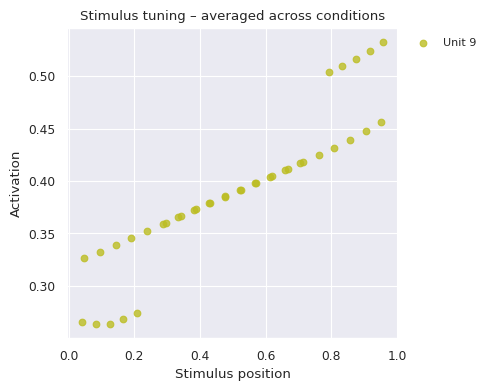

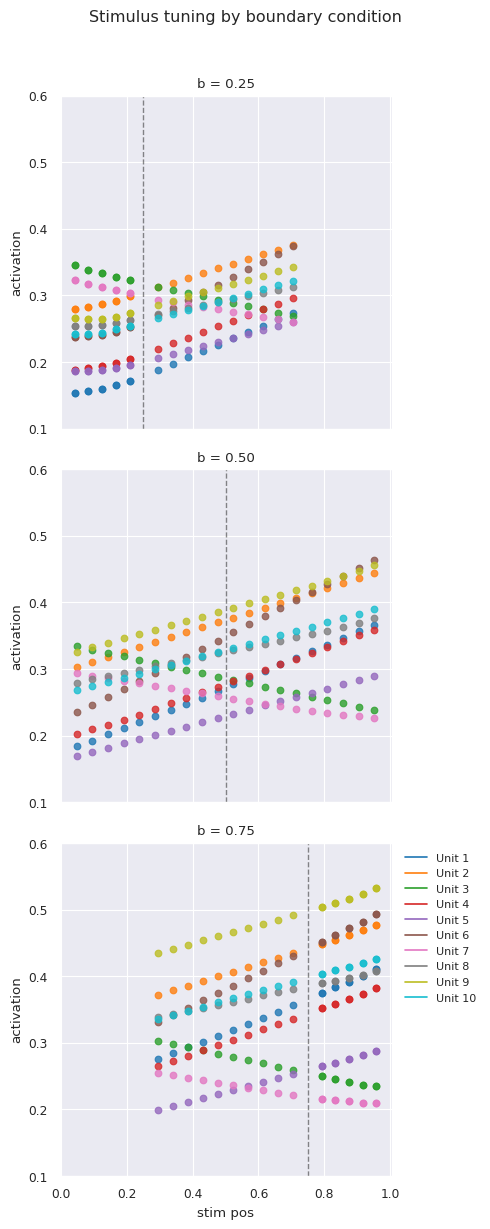

In [24]:
plt.close('all')

n_units = hidden_mean.shape[1]  # 10
unit_colors = plt.cm.tab10(np.linspace(0, 1, n_units))
unit_labels = [f'Unit {i+1}' for i in range(n_units)]

# align hidden activations with pca_df rows
tuning_df = pca_df[['boundary', 'stim']].copy().reset_index(drop=True)
for i in range(n_units):
    tuning_df[f'unit_{i}'] = hidden_mean[:, i]

# ── Plot 1: averaged across conditions (1 point per stim per unit) ────────────
unit_cols = [f'unit_{i}' for i in range(n_units)]
avg_df = tuning_df.groupby('stim')[unit_cols].mean().reset_index().sort_values('stim')

fig, ax = plt.subplots(figsize=(5, 4))
for i in range(n_units):
    if i!=8: continue
    ax.scatter(avg_df['stim'], avg_df[f'unit_{i}'],
               color=unit_colors[i], label=unit_labels[i], alpha=0.8)
ax.set_title('Stimulus tuning – averaged across conditions')
ax.set_xlabel('Stimulus position')
ax.set_ylabel('Activation')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

# ── Plots 2–4: separated by boundary condition ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(5, 12), sharex=True)
for ax, bound in zip(axes, boundaries):
    cond_df = tuning_df[tuning_df['boundary'] == bound].sort_values('stim')
    for i in range(n_units):
        ax.scatter(cond_df['stim'], cond_df[f'unit_{i}'],
                color=unit_colors[i], label=unit_labels[i], alpha=0.8)
    ax.axvline(bound, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.set(ylabel='activation', ylim=(.1, .6), title=f'b = {bound:.2f}')
axes[2].set_xlabel('stim pos')

# single shared legend outside the bottom panel
handles = [plt.Line2D([0], [0], color=unit_colors[i], label=unit_labels[i]) for i in range(n_units)]
axes[-1].legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)

plt.suptitle('Stimulus tuning by boundary condition', y=1.02)
plt.tight_layout()
plt.show()


In [25]:
for bound in boundaries:
    stims = sorted(pca_df[pca_df["boundary"] == bound]["stim"].values)
    print(f"b={bound:.2f}  n={len(stims)}  stims={list(round(float(s),3) for s in stims)}")

b=0.25  n=20  stims=[0.042, 0.042, 0.083, 0.083, 0.125, 0.125, 0.167, 0.167, 0.208, 0.208, 0.295, 0.341, 0.386, 0.432, 0.477, 0.523, 0.568, 0.614, 0.659, 0.705]
b=0.50  n=20  stims=[0.048, 0.095, 0.143, 0.19, 0.238, 0.286, 0.333, 0.381, 0.429, 0.476, 0.524, 0.571, 0.619, 0.667, 0.714, 0.762, 0.81, 0.857, 0.905, 0.952]
b=0.75  n=20  stims=[0.295, 0.341, 0.386, 0.432, 0.477, 0.523, 0.568, 0.614, 0.659, 0.705, 0.792, 0.792, 0.833, 0.833, 0.875, 0.875, 0.917, 0.917, 0.958, 0.958]


class modulation

context modulation